Lattice IIR Filter Coefficients:
Reflection Coefficients (K):
[-3.13076407  3.7523345  -2.0292437   0.41688331]
Ladder Coefficients (V):
[ 0.01248382  3.13076407 -3.7523345   2.0292437  -0.41688331]


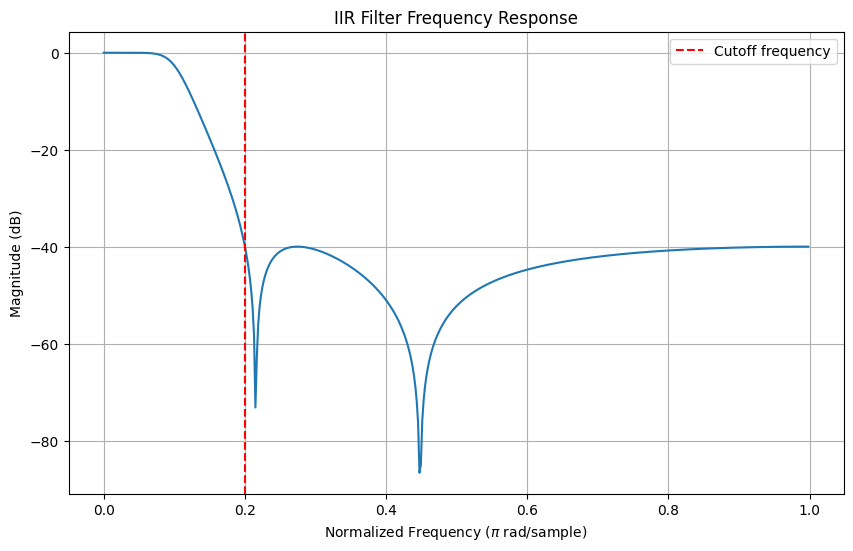

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define the filter specifications
nyquist_freq = 1.0  # Normalized Nyquist frequency
cutoff_freq = 0.2   # Normalized cutoff frequency
passband_ripple = 0.1  # Passband ripple in dB
stopband_atten = 40    # Stopband attenuation in dB

# Design the IIR filter
b, a = signal.cheby2(4, stopband_atten, cutoff_freq / nyquist_freq, btype='low', analog=False, output='ba')

# Extract the lattice filter coefficients
# This was taken from asking Claude Haiku on how to do this. No idea how/why it works.
k = a[1:]  # Reflection coefficients (K)
v = np.concatenate(([b[0] / a[0]], -a[1:] / a[0]))  # Ladder coefficients (V)

# Print the coefficients
print("Lattice IIR Filter Coefficients:")
print("Reflection Coefficients (K):")
print(k)
print("Ladder Coefficients (V):")
print(v)

# Compute the frequency response
w, h = signal.freqz(b, a)

# Plot the frequency response
plt.figure(figsize=(10, 6))
plt.plot(w / np.pi, 20 * np.log10(np.abs(h)))
plt.axvline(x=cutoff_freq / nyquist_freq, color='r', linestyle='--', label='Cutoff frequency')
plt.xlabel('Normalized Frequency ($\pi$ rad/sample)')
plt.ylabel('Magnitude (dB)')
plt.title('IIR Filter Frequency Response')
plt.grid()
plt.legend()
plt.show()